# Training visualization — LGD

End-to-end view of every continued-pretraining trial that
`scripts/train_pipeline.py` has produced — per-epoch loss/metric
curves, learning-rate schedule, cross-trial comparisons,
convergence diagnostics, and resource-usage trade-offs.

## Where the data comes from

Two artefacts written by the training pipeline:

* **Per-epoch CSV** — one file per trial under
  `output/training/epochs/<track>/<descriptive_name>.csv` with the
  schema `(epoch, train_loss, lr, metric_name, train_metric,
  test_metric, epoch_time_sec, elapsed_sec)`.
* **Run manifest CSV** — `output/training/manifests/<run_name>_<track>.csv`,
  one row per trial: hyperparameters, status (OK / FAIL), total
  walltime, the path of the final-epoch checkpoint.

All loading and plotting code lives in
`src/utils/training_viz.py`; this notebook contains only function
calls so the notebook stays scannable and the logic stays testable.

## What a 'trial' is

One trial = one `(base_checkpoint × learning_rate × use_lora)` tuple
from `cfg.tunable` in `config/train.yaml`. The full grid is the
Cartesian product, so a four-base / four-LR / {no-LoRA, LoRA}
sweep is 32 trials per track. SLURM array indices map 1-to-1 onto
trial indices.

## Direction of improvement

Higher is better for PD (`roc_auc`); lower is better for LGD
(`rmse`). Every helper in this notebook is direction-aware — `best`
and `sort_values` calls flip sign automatically.

## Sections

1. Setup and what's on disk
2. Per-trial dashboards (one model at a time)
3. Cross-trial loss & metric curves
4. Final-metric comparisons by hyperparameter
5. Time / accuracy trade-off
6. Convergence diagnostics
7. Failures and leaderboard

In [1]:
%matplotlib inline
import sys, os
from pathlib import Path
REPO = Path(os.getcwd()).resolve()
while not (REPO / 'src' / 'utils' / 'training_viz.py').exists() and REPO.parent != REPO:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import pandas as pd
from src.utils.figures import open_figure_sink
from src.utils.training_viz import (
    load_run_manifest, load_epoch_history, load_all_epoch_histories,
    training_overview, trial_leaderboard, failed_trials,
    plot_loss_curve, plot_lr_schedule, plot_metric_curves,
    plot_epoch_time, plot_trial_dashboard,
    plot_loss_overlay, plot_metric_overlay, plot_overfitting_diagnostic,
    plot_final_metric_bar, plot_lr_effect, plot_lora_effect,
    plot_metric_heatmap, plot_base_ranking,
    plot_pareto_time_vs_metric, plot_epoch_time_overlay,
    plot_convergence_speed,
)
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)
TRACK = 'lgd'    # this notebook is fixed to the LGD track
sink = open_figure_sink('1.1_training_visualization_lgd')


## 1 · What's on disk

Manifest tells us which trials were attempted and their outcome;
the per-epoch CSV count tells us how many of those produced any
training history.

In [2]:
manifest = load_run_manifest(TRACK)
manifest

,track,base_checkpoint,learning_rate,use_lora,query_fraction,accumulate_grad_batches,seed,n_train_datasets,n_test_datasets,final_ckpt_path,elapsed_sec,status,error,primary_metric_name,baseline_train_metric,baseline_test_metric,final_train_metric,final_test_metric,final_train_loss,secondary_metric_name,final_secondary_train,final_secondary_test,diverged_at_epoch,diverge_reason,epoch_pass_mode,trial_name,base_short,lr_tag
0,lgd,checkpoints/tabpfn-v3-regressor-v3_default.ckpt,3.000000e-07,False,0.2,1,42,6,2,/data/leuven/383/vsc38338/CreditPFN/checkpoint...,799.909500,OK,NaN,rmse,0.349980,0.150758,0.346345,0.136561,0.772512,r2,-21.220722,0.732360,NaN,NaN,one_sample,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,3e-07
1,lgd,checkpoints/tabpfn-v3-regressor-v3_default.ckpt,3.000000e-07,False,0.2,1,42,6,2,/data/leuven/383/vsc38338/CreditPFN/checkpoint...,900.940986,OK,NaN,rmse,0.349980,0.150758,0.346131,0.136347,0.405416,r2,-21.294486,0.733273,NaN,NaN,full_pass,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,3e-07
2,lgd,checkpoints/tabpfn-v3-regressor-v3_default.ckpt,3.000000e-07,True,0.2,1,42,6,2,/data/leuven/383/vsc38338/CreditPFN/checkpoint...,801.110833,OK,NaN,rmse,0.349980,0.150758,0.351141,0.136896,1.236810,r2,-23.001611,0.731011,NaN,NaN,one_sample,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,3e-07
3,lgd,checkpoints/tabpfn-v3-regressor-v3_default.ckpt,3.000000e-07,True,0.2,1,42,6,2,/data/leuven/383/vsc38338/CreditPFN/checkpoint...,911.063105,OK,NaN,rmse,0.349980,0.150758,0.351054,0.136831,1.679852,r2,-22.989245,0.731267,NaN,NaN,full_pass,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,3e-07
4,lgd,checkpoints/tabpfn-v3-regressor-v3_default.ckpt,1.000000e-06,False,0.2,1,42,6,2,/data/leuven/383/vsc38338/CreditPFN/checkpoint...,818.406699,OK,NaN,rmse,0.349980,0.150758,0.346463,0.136319,0.434045,r2,-21.167456,0.733410,NaN,NaN,one_sample,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,1e-06
5,lgd,checkpoints/tabpfn-v3-regressor-v3_default.ckpt,1.000000e-06,False,0.2,1,42,6,2,/data/leuven/383/vsc38338/CreditPFN/checkpoint...,923.203411,OK,NaN,rmse,0.349980,0.150758,0.345681,0.136688,-0.006737,r2,-20.741993,0.732067,NaN,NaN,full_pass,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,1e-06
6,lgd,checkpoints/tabpfn-v3-regressor-v3_default.ckpt,1.000000e-06,True,0.2,1,42,6,2,/data/leuven/383/vsc38338/CreditPFN/checkpoint...,794.377124,OK,NaN,rmse,0.349980,0.150758,0.351053,0.136847,1.183414,r2,-22.937056,0.731199,NaN,NaN,one_sample,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,1e-06
7,lgd,checkpoints/tabpfn-v3-regressor-v3_default.ckpt,1.000000e-06,True,0.2,1,42,6,2,/data/leuven/383/vsc38338/CreditPFN/checkpoint...,903.358120,OK,NaN,rmse,0.349980,0.150758,0.350859,0.136829,1.462481,r2,-22.899666,0.731248,NaN,NaN,full_pass,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,1e-06
8,lgd,checkpoints/tabpfn-v3-regressor-v3_default.ckpt,1.000000e-05,False,0.2,1,42,6,2,/data/leuven/383/vsc38338/CreditPFN/checkpoint...,801.271696,OK,NaN,rmse,0.349980,0.150758,0.355006,0.138575,0.019177,r2,-22.086636,0.724484,NaN,NaN,one_sample,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,1e-05
9,lgd,checkpoints/tabpfn-v3-regressor-v3_default.ckpt,1.000000e-05,False,0.2,1,42,6,2,/data/leuven/383/vsc38338/CreditPFN/checkpoint...,903.225158,OK,NaN,rmse,0.349980,0.150758,0.355721,0.140829,-0.559265,r2,-22.895113,0.715273,NaN,NaN,full_pass,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,1e-05


In [3]:
overview = training_overview(TRACK)
overview

,trial_name,base_short,base_checkpoint,learning_rate,use_lora,seed,status,elapsed_sec,n_train_datasets,n_test_datasets,n_epochs,final_train_loss,final_train_metric,final_test_metric,best_test_metric,best_epoch,metric_name,mean_epoch_sec
0,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,checkpoints/tabpfn-v3-regressor-v3_default.ckpt,3.000000e-07,False,42,OK,799.909500,6,2,51,0.772512,0.346345,0.136561,0.121801,40,rmse,15.354607
1,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,checkpoints/tabpfn-v3-regressor-v3_default.ckpt,3.000000e-07,False,42,OK,900.940986,6,2,51,0.405416,0.346131,0.136347,0.121762,40,rmse,17.348391
2,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,checkpoints/tabpfn-v3-regressor-v3_default.ckpt,3.000000e-07,True,42,OK,801.110833,6,2,51,1.236810,0.351141,0.136896,0.121966,40,rmse,15.376409
3,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,checkpoints/tabpfn-v3-regressor-v3_default.ckpt,3.000000e-07,True,42,OK,911.063105,6,2,51,1.679852,0.351054,0.136831,0.121926,40,rmse,17.536920
4,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,checkpoints/tabpfn-v3-regressor-v3_default.ckpt,1.000000e-06,False,42,OK,818.406699,6,2,51,0.434045,0.346463,0.136319,0.121558,40,rmse,15.720123
5,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,checkpoints/tabpfn-v3-regressor-v3_default.ckpt,1.000000e-06,False,42,OK,923.203411,6,2,51,-0.006737,0.345681,0.136688,0.121338,40,rmse,17.774556
6,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,checkpoints/tabpfn-v3-regressor-v3_default.ckpt,1.000000e-06,True,42,OK,794.377124,6,2,51,1.183414,0.351053,0.136847,0.121930,40,rmse,15.244112
7,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,checkpoints/tabpfn-v3-regressor-v3_default.ckpt,1.000000e-06,True,42,OK,903.358120,6,2,51,1.462481,0.350859,0.136829,0.121883,40,rmse,17.381658
8,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,checkpoints/tabpfn-v3-regressor-v3_default.ckpt,1.000000e-05,False,42,OK,801.271696,6,2,51,0.019177,0.355006,0.138575,0.123822,40,rmse,15.384543
9,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,checkpoints/tabpfn-v3-regressor-v3_default.ckpt,1.000000e-05,False,42,OK,903.225158,6,2,51,-0.559265,0.355721,0.140829,0.123773,40,rmse,17.388080


## 2 · Per-trial dashboard

Pick one trial (any descriptive_name from the leaderboard). The
dashboard gives a 2×2 view of `loss`, `lr`, `train/test metric`,
and `epoch wall-clock` — useful for spotting one slow chunk, an
exploding loss, or a metric that's still climbing at the cliff.

In [4]:
# Default: the best-scoring trial in the overview. Override with any
# trial_name string to inspect that one instead.
FOCUS_TRIAL = (
    overview.sort_values('best_test_metric', ascending=(TRACK == 'lgd'))['trial_name'].iloc[0]
    if not overview.empty else 'creditpfn_pd_tabpfn-v3-classifier-v3_default_lr5e-05_seed42'
)
FOCUS_TRIAL

'creditpfn_lgd_tabpfn-v3-regressor-v3_default_lr1e-06_seed42_qf20_acc1_fullpass'

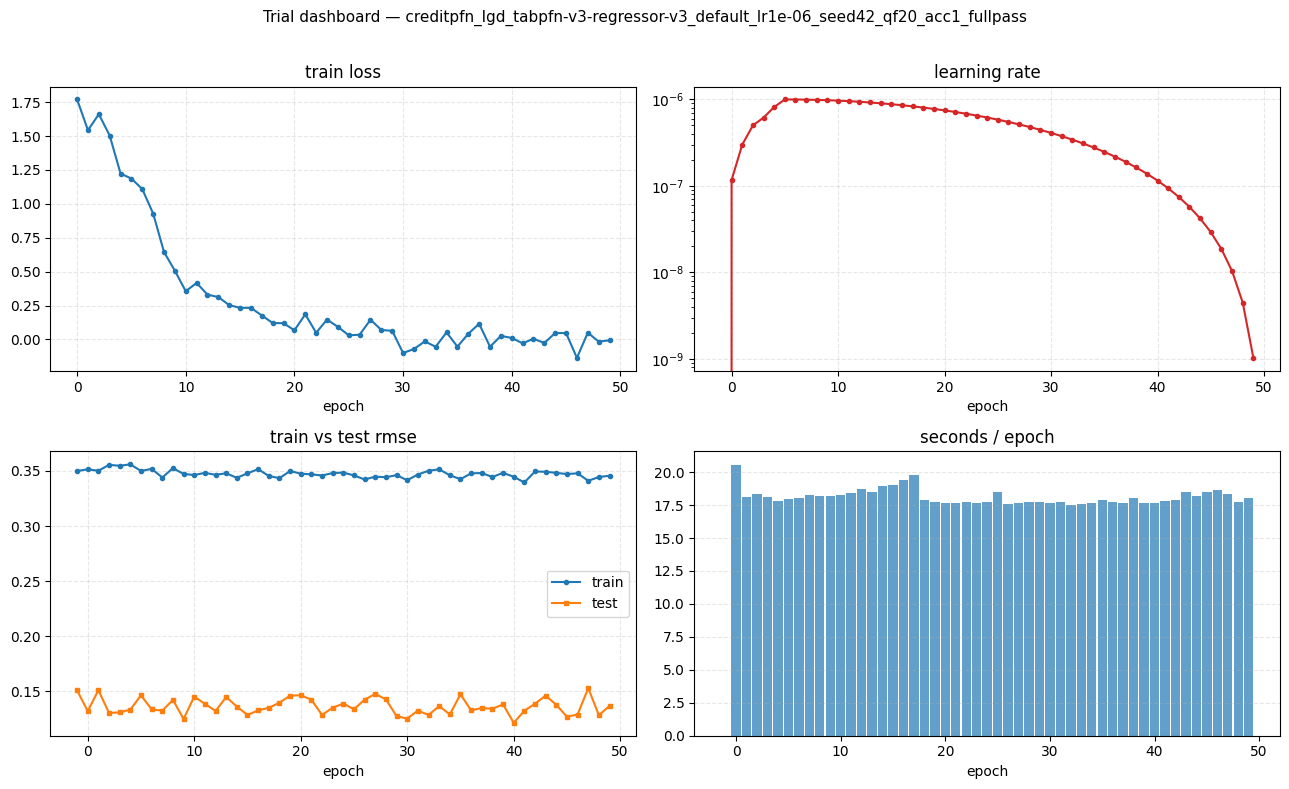

In [5]:
sink.save(plot_trial_dashboard(FOCUS_TRIAL, TRACK), '01_trial_dashboard')

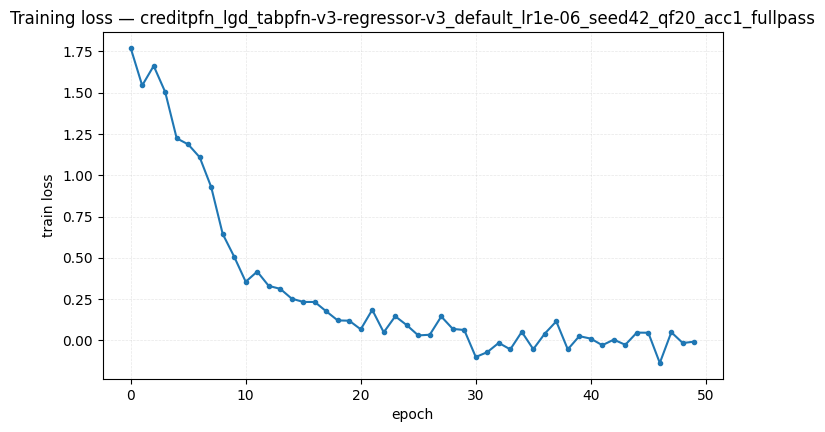

In [6]:
sink.save(plot_loss_curve(FOCUS_TRIAL, TRACK), '02_loss_curve')

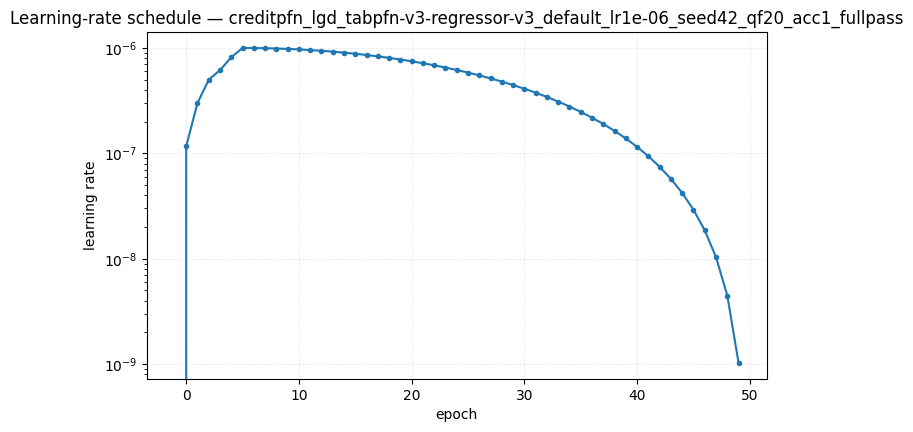

In [7]:
sink.save(plot_lr_schedule(FOCUS_TRIAL, TRACK), '03_lr_schedule')

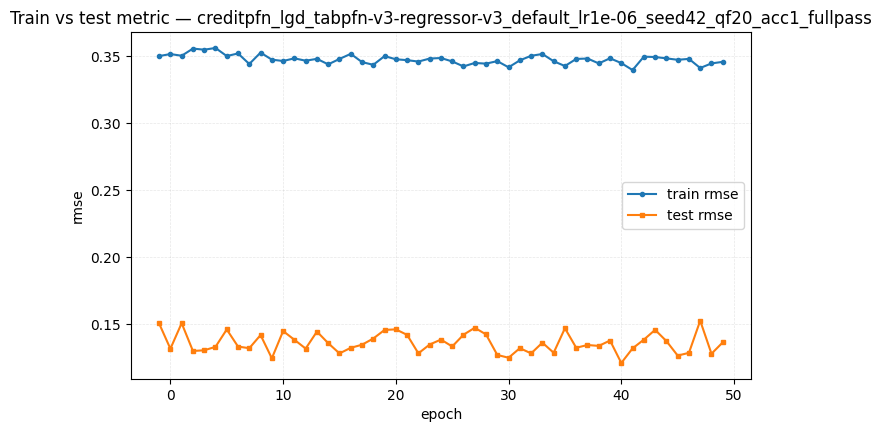

In [8]:
sink.save(plot_metric_curves(FOCUS_TRIAL, TRACK), '04_metric_curves')

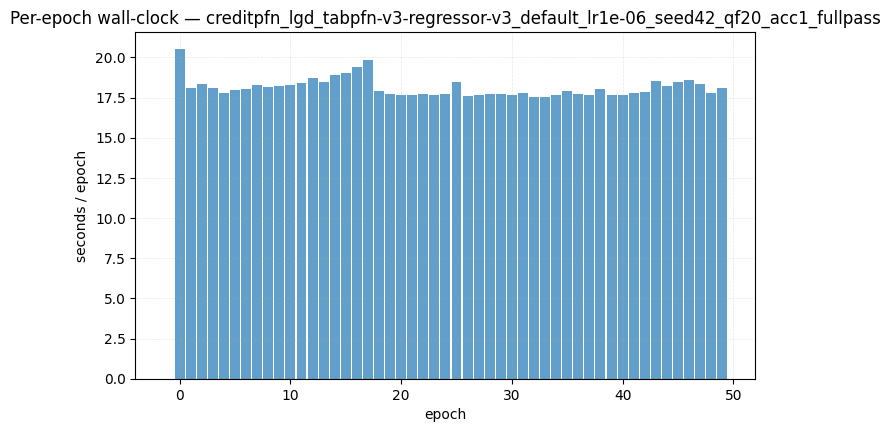

In [9]:
sink.save(plot_epoch_time(FOCUS_TRIAL, TRACK), '05_epoch_time')

## 3 · Cross-trial overlays

Every trial on one axes. Colour = base checkpoint;
solid = no-LoRA, dashed = LoRA. Use these to spot regimes:

* If LoRA trials cluster well below no-LoRA ⇒ LoRA is hurting on
  this track and base.
* If one base sits clearly above the others throughout ⇒ pick that
  base as the headline checkpoint.
* If test_metric falls while train_metric keeps climbing ⇒ overfit
  starting; check the gap plot.

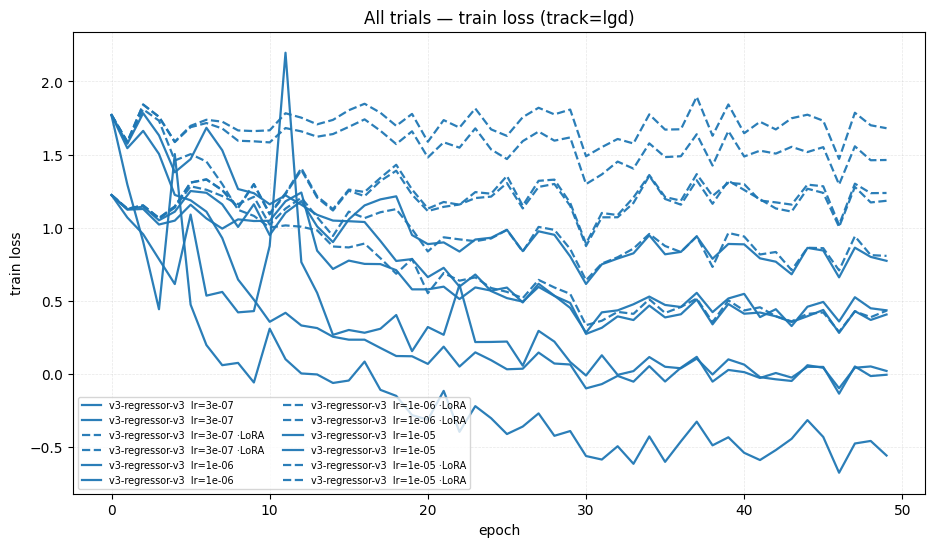

In [10]:
sink.save(plot_loss_overlay(TRACK), '06_loss_overlay')

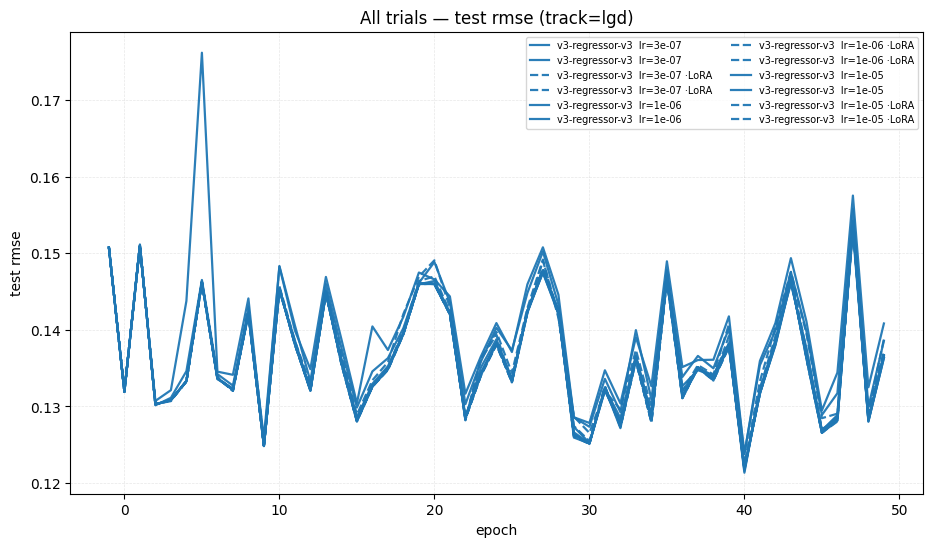

In [11]:
sink.save(plot_metric_overlay(TRACK, split='test'), '07_metric_overlay')

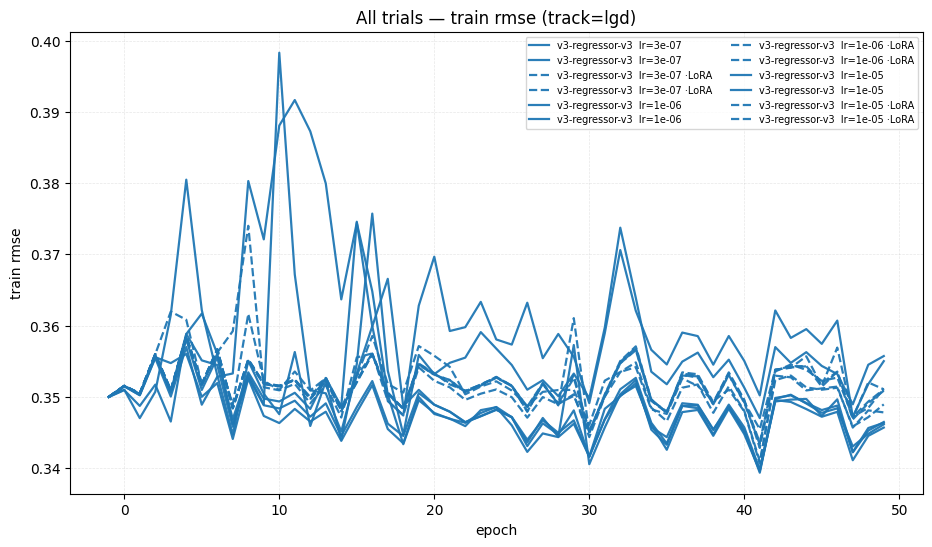

In [12]:
sink.save(plot_metric_overlay(TRACK, split='train'), '08_metric_overlay')

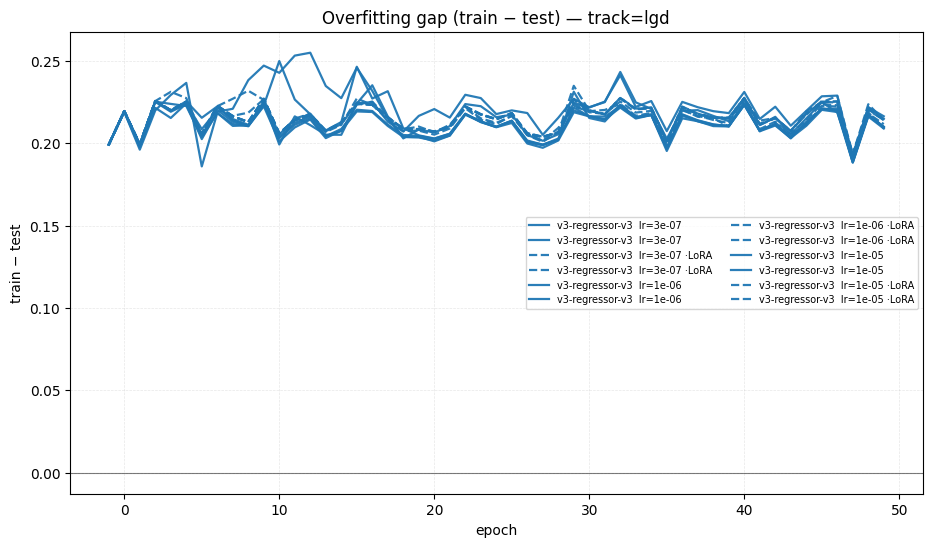

In [13]:
sink.save(plot_overfitting_diagnostic(TRACK), '09_overfitting_diagnostic')

## 4 · Final-metric comparisons by hyperparameter

**`best_test_metric`** is the best test-set score the trial
achieved during training (max of `test_metric` for PD,
min for LGD).

**`final_test_metric`** is the last-epoch value (i.e. what the
checkpoint actually delivers on disk).

Swap the `metric=` kwarg below to view the latter instead.

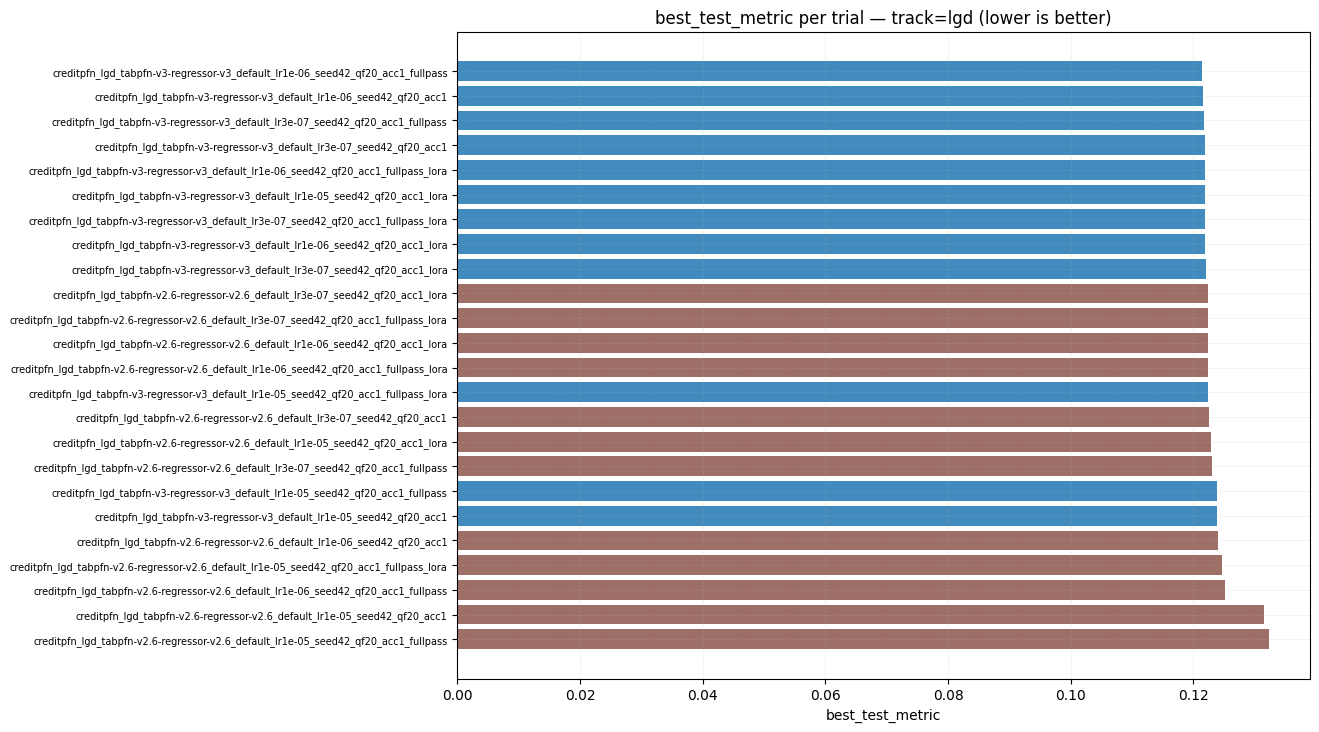

In [14]:
sink.save(plot_final_metric_bar(TRACK, metric='best_test_metric'), '10_final_metric_bar')

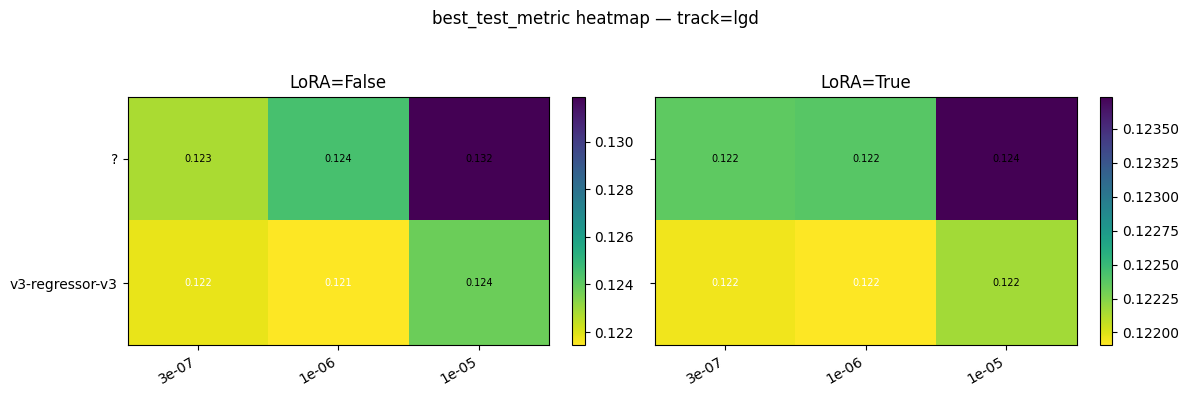

In [15]:
sink.save(plot_metric_heatmap(TRACK, metric='best_test_metric'), '11_metric_heatmap')

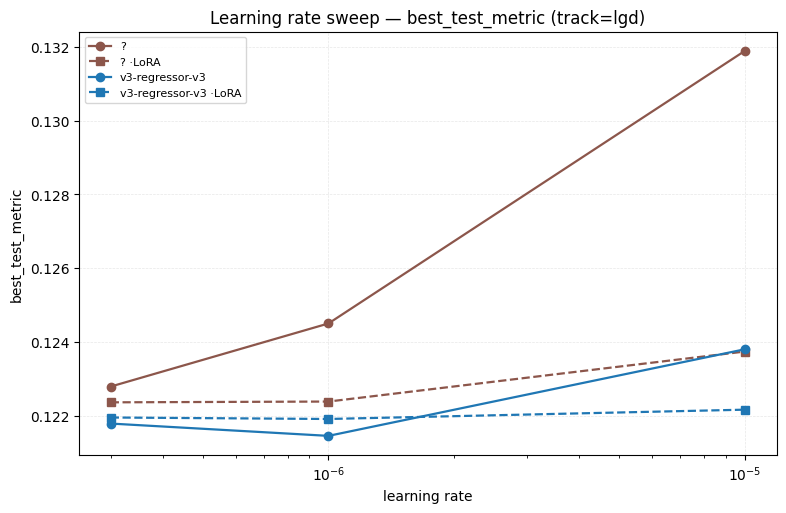

In [16]:
sink.save(plot_lr_effect(TRACK, metric='best_test_metric'), '12_lr_effect')

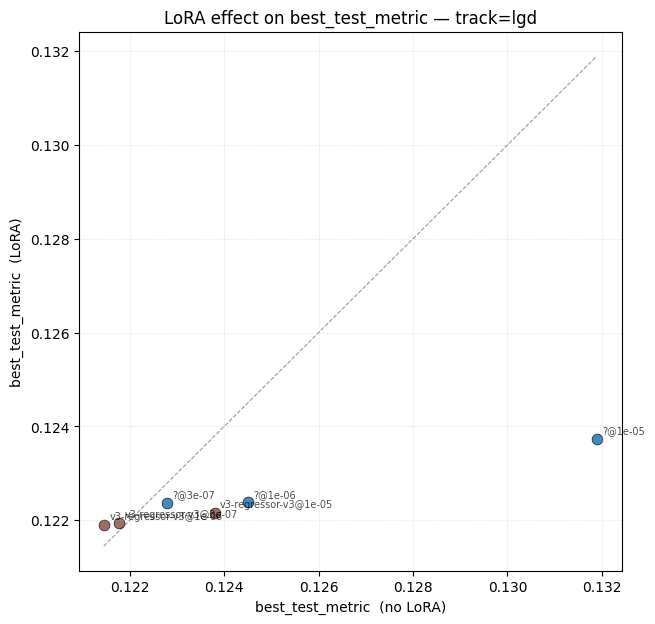

In [17]:
sink.save(plot_lora_effect(TRACK, metric='best_test_metric'), '13_lora_effect')

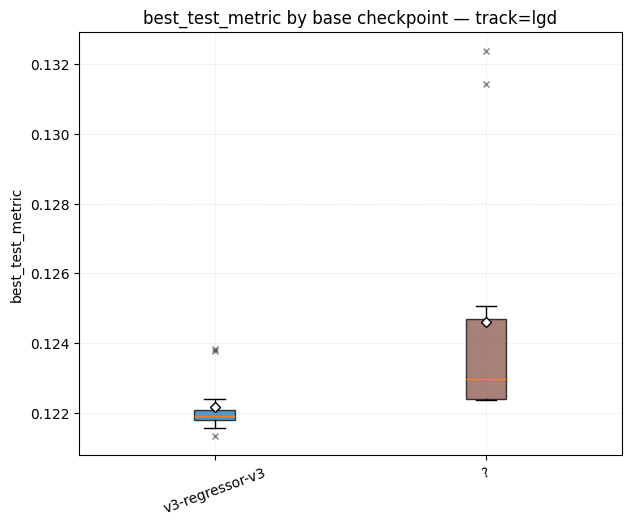

In [18]:
sink.save(plot_base_ranking(TRACK, metric='best_test_metric'), '14_base_ranking')

## 5 · Time / accuracy trade-off

The Pareto-frontier-style scatter pairs **total training time** (x,
minutes) with the **final-epoch test metric** (y). A trial that
matches another's metric in less time pareto-dominates it.

The per-epoch bar plot underneath flags trials whose mean
seconds/epoch is unusually high — useful when one dataset's
chunk drags the whole epoch budget.

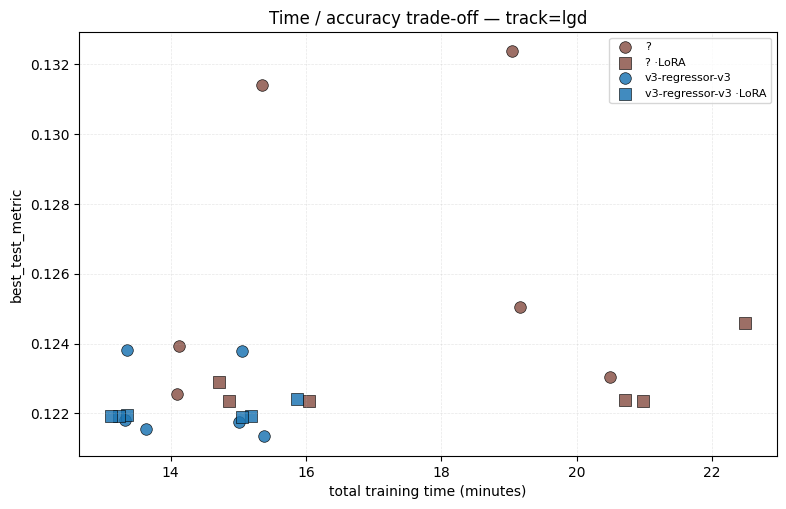

In [19]:
sink.save(plot_pareto_time_vs_metric(TRACK, metric='best_test_metric'), '15_pareto_time_vs_metric')

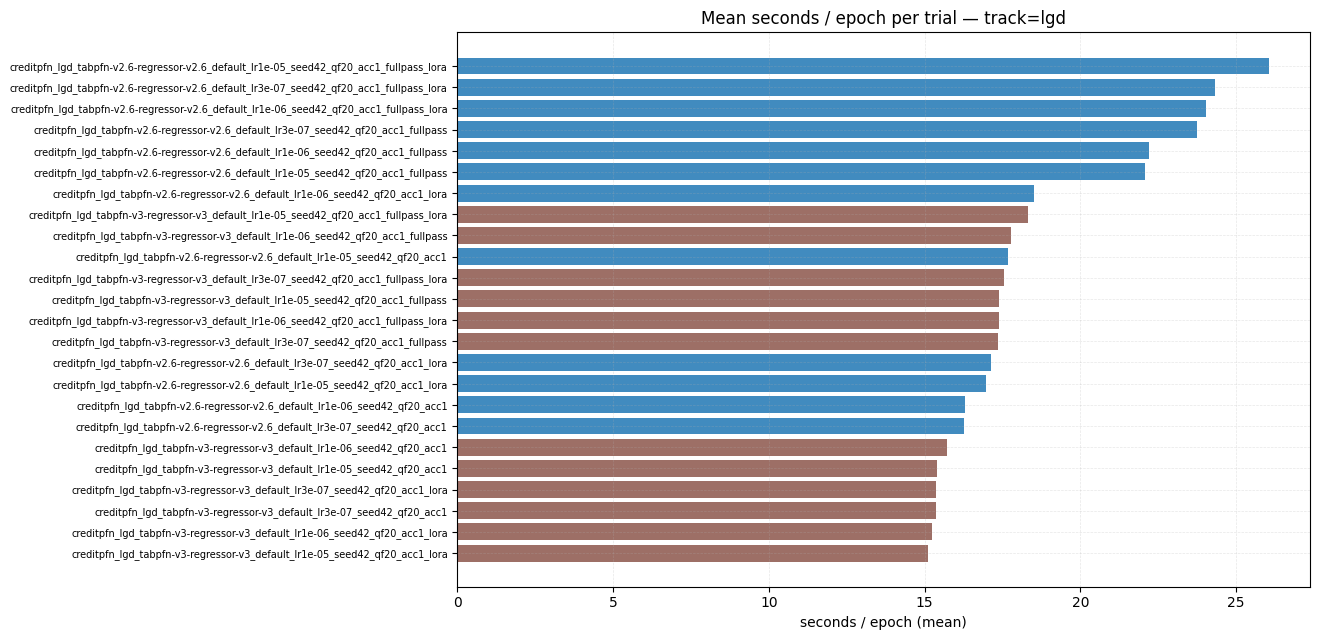

In [20]:
sink.save(plot_epoch_time_overlay(TRACK), '16_epoch_time_overlay')

## 6 · Convergence diagnostics

Where in the training budget does the best test metric appear?

* Most mass at < 30 % ⇒ early stop is leaving training cycles on
  the floor; consider shorter epochs or a stricter LR schedule.
* Most mass at > 80 % ⇒ trials are still improving when training
  ends; increase `cfg.train.epochs` before re-launching the sweep.

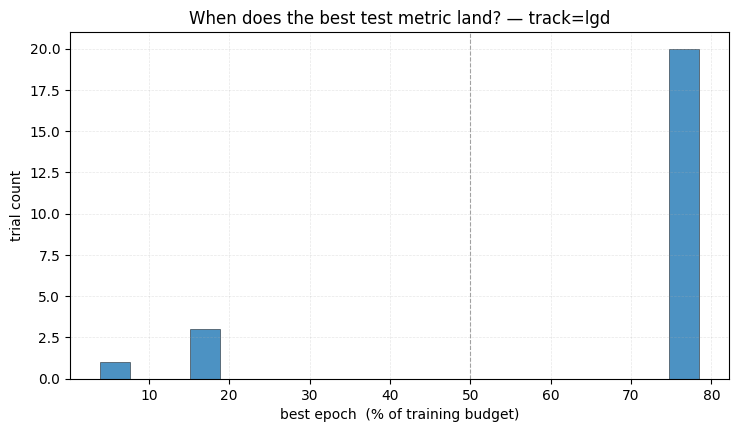

In [21]:
sink.save(plot_convergence_speed(TRACK), '17_convergence_speed')

## 7 · Failures and leaderboard

`failed_trials()` surfaces any FAIL rows from the manifest with
their error string — most often a `CUDA OOM` from a too-large
`n_finetune_ctx_plus_query_samples`. The leaderboard at the end
is the canonical sorted view used to pick the headline
checkpoint for eval.

In [22]:
failures = failed_trials(TRACK)
if failures.empty:
    print('No failed trials. ✔')
else:
    display(failures)

No failed trials. ✔


In [23]:
trial_leaderboard(TRACK)

,trial_name,base_short,learning_rate,use_lora,seed,metric_name,best_test_metric,best_epoch,final_test_metric,final_train_metric,n_epochs,mean_epoch_sec,elapsed_sec,status
0,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,1.000000e-06,False,42,rmse,0.121338,40,0.136688,0.345681,51,17.774556,923.203411,OK
1,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,1.000000e-06,False,42,rmse,0.121558,40,0.136319,0.346463,51,15.720123,818.406699,OK
2,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,3.000000e-07,False,42,rmse,0.121762,40,0.136347,0.346131,51,17.348391,900.940986,OK
3,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,3.000000e-07,False,42,rmse,0.121801,40,0.136561,0.346345,51,15.354607,799.909500,OK
4,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,1.000000e-06,True,42,rmse,0.121883,40,0.136829,0.350859,51,17.381658,903.358120,OK
5,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,1.000000e-05,True,42,rmse,0.121912,40,0.137268,0.348936,51,15.102079,786.924776,OK
6,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,3.000000e-07,True,42,rmse,0.121926,40,0.136831,0.351054,51,17.536920,911.063105,OK
7,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,1.000000e-06,True,42,rmse,0.121930,40,0.136847,0.351053,51,15.244112,794.377124,OK
8,creditpfn_lgd_tabpfn-v3-regressor-v3_default_l...,v3-regressor-v3,3.000000e-07,True,42,rmse,0.121966,40,0.136896,0.351141,51,15.376409,801.110833,OK
9,creditpfn_lgd_tabpfn-v2.6-regressor-v2.6_defau...,?,3.000000e-07,True,42,rmse,0.122356,40,0.139216,0.353727,51,17.144996,891.424672,OK
